Original image loaded successfully.

Original Image Information
---------------------------
Width  : 1920 pixels
Height : 1080 pixels
Total pixels : 2073600


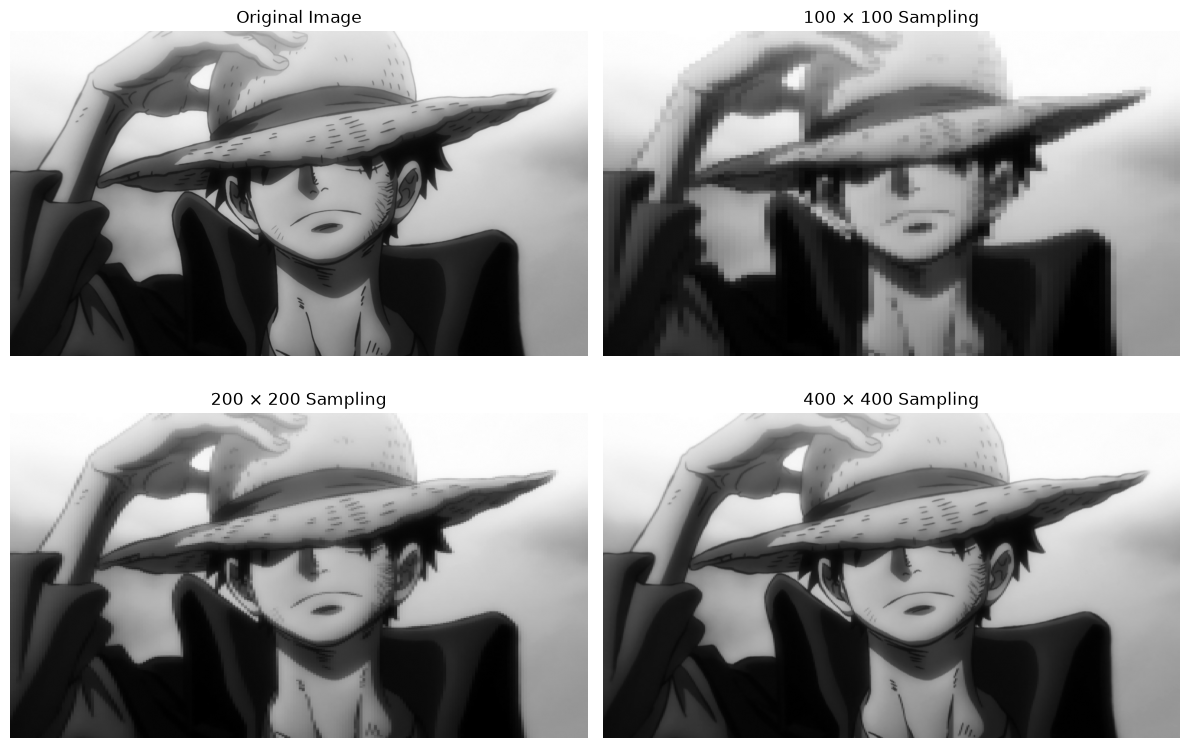

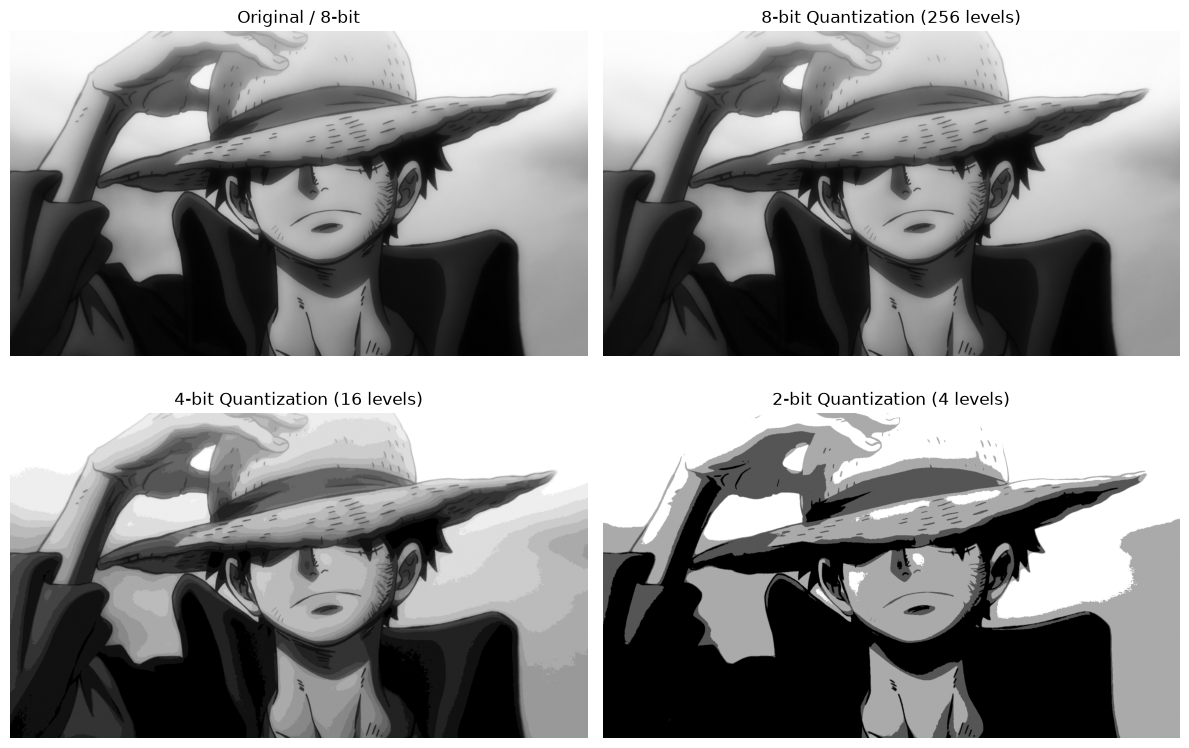


Quantized images saved successfully.

Gray-Level Information
----------------------
8-bit :  256 gray levels
4-bit :  16 gray levels
2-bit :  4 gray levels

Theoretical Storage Requirements
---------------------------------
8-bit : 16588800 bits
4-bit : 8294400 bits
2-bit : 4147200 bits

Storage in bytes
8-bit : 2073600.0 bytes
4-bit : 1036800.0 bytes
2-bit : 518400.0 bytes

Storage Savings Compared with 8-bit
------------------------------------
4-bit savings : 50.0 %
2-bit savings : 75.0 %

Final Comparison
----------------
8-bit : Highest visual quality, 256 gray levels
4-bit : Moderate visual quality, 16 gray levels
2-bit : Lowest visual quality, 4 gray levels

Image sampling reduces spatial resolution.
Gray-level quantization reduces intensity resolution.

Program completed successfully.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Read the image in grayscale
# -------------------------------------------------

image = cv2.imread("luffy.jpg", cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found!")
    exit()

print("Original image loaded successfully.")

# Original dimensions
height, width = image.shape

print("\nOriginal Image Information")
print("---------------------------")
print("Width  :", width, "pixels")
print("Height :", height, "pixels")
print("Total pixels :", width * height)


# -------------------------------------------------
# 2. Image Sampling
# -------------------------------------------------

# Sampling means reducing the spatial resolution.
# Three different sampling resolutions are created.

sample_100 = cv2.resize(image, (100, 100),interpolation=cv2.INTER_AREA)

sample_200 = cv2.resize(image, (200, 200), interpolation=cv2.INTER_AREA)

sample_400 = cv2.resize(image, (400, 400), interpolation=cv2.INTER_AREA)


# Resize them back to the original display size
# so that visual comparison is easier.

sample_100_display = cv2.resize(
    sample_100, (width, height),
    interpolation=cv2.INTER_NEAREST
)

sample_200_display = cv2.resize(
    sample_200, (width, height),
    interpolation=cv2.INTER_NEAREST
)

sample_400_display = cv2.resize(
    sample_400, (width, height),
    interpolation=cv2.INTER_NEAREST
)


# -------------------------------------------------
# 3. Gray-Level Quantization Function
# -------------------------------------------------

def quantize_image(image, bits):

    levels = 2 ** bits

    # Convert intensity range 0-255
    # into the required number of levels.

    quantized = np.floor(
        image / 256 * levels
    ) * (256 / levels)

    quantized = np.clip(
        quantized, 0, 255
    ).astype(np.uint8)

    return quantized


# -------------------------------------------------
# 4. Quantization at Different Bit Depths
# -------------------------------------------------

quant_8bit = quantize_image(image, 8)
quant_4bit = quantize_image(image, 4)
quant_2bit = quantize_image(image, 2)


# -------------------------------------------------
# 5. Display Sampling Results
# -------------------------------------------------

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sample_100_display, cmap="gray")
plt.title("100 × 100 Sampling")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(sample_200_display, cmap="gray")
plt.title("200 × 200 Sampling")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(sample_400_display, cmap="gray")
plt.title("400 × 400 Sampling")
plt.axis("off")

plt.tight_layout()
plt.show()


# -------------------------------------------------
# 6. Display Quantization Results
# -------------------------------------------------

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original / 8-bit")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(quant_8bit, cmap="gray")
plt.title("8-bit Quantization (256 levels)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(quant_4bit, cmap="gray")
plt.title("4-bit Quantization (16 levels)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(quant_2bit, cmap="gray")
plt.title("2-bit Quantization (4 levels)")
plt.axis("off")

plt.tight_layout()
plt.show()


# -------------------------------------------------
# 7. Save the Quantized Images
# -------------------------------------------------

cv2.imwrite("quantized_8bit.jpg", quant_8bit)
cv2.imwrite("quantized_4bit.jpg", quant_4bit)
cv2.imwrite("quantized_2bit.jpg", quant_2bit)

print("\nQuantized images saved successfully.")


# -------------------------------------------------
# 8. Calculate Gray Levels
# -------------------------------------------------

levels_8 = 2 ** 8
levels_4 = 2 ** 4
levels_2 = 2 ** 2

print("\nGray-Level Information")
print("----------------------")
print("8-bit : ", levels_8, "gray levels")
print("4-bit : ", levels_4, "gray levels")
print("2-bit : ", levels_2, "gray levels")


# -------------------------------------------------
# 9. Calculate Theoretical Storage Requirements
# -------------------------------------------------

total_pixels = height * width

storage_8 = total_pixels * 8
storage_4 = total_pixels * 4
storage_2 = total_pixels * 2

print("\nTheoretical Storage Requirements")
print("---------------------------------")

print("8-bit :", storage_8, "bits")
print("4-bit :", storage_4, "bits")
print("2-bit :", storage_2, "bits")

print("\nStorage in bytes")

print("8-bit :", storage_8 / 8, "bytes")
print("4-bit :", storage_4 / 8, "bytes")
print("2-bit :", storage_2 / 8, "bytes")


# -------------------------------------------------
# 10. Storage Savings
# -------------------------------------------------

saving_4 = (1 - storage_4 / storage_8) * 100
saving_2 = (1 - storage_2 / storage_8) * 100

print("\nStorage Savings Compared with 8-bit")
print("------------------------------------")
print("4-bit savings :", saving_4, "%")
print("2-bit savings :", saving_2, "%")


# -------------------------------------------------
# 11. Display Summary
# -------------------------------------------------

print("\nFinal Comparison")
print("----------------")
print("8-bit : Highest visual quality, 256 gray levels")
print("4-bit : Moderate visual quality, 16 gray levels")
print("2-bit : Lowest visual quality, 4 gray levels")

print("\nImage sampling reduces spatial resolution.")
print("Gray-level quantization reduces intensity resolution.")
print("\nProgram completed successfully.")

